# 3ARM-VS-4ARM Experiment Visualization

Comprehensive visualization of the 3ARM-VS-4ARM experiment results.

**Methods compared:**
- **GA-LLAMEA-3arm** — GA-LLAMEA with 3 operators: mutation, crossover, random_new
- **GA-LLAMEA-4arm** — GA-LLAMEA with 4 operators: mutation, crossover, random_new, refine_weakness

**Problem:** MA_BBOB (dims=[5], budget_factor=2000, LLM budget=100)

**Sections:**
1. Setup and Data Loading
2. Convergence Plots
3. CEG (Code Evolution Graphs)
4. GA-LLAMEA Arm Selection Percentages
5. Boxplots (Fitness Comparison)
6. Fitness Table (Statistical Summary)
7. Behavior Metrics Analysis
8. Summary and Comparison

## 1. Setup and Data Loading

In [1]:
# Core imports
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# BLADE imports
from iohblade.loggers import ExperimentLogger
from iohblade.plots import (
    plot_convergence,
    plot_experiment_CEG,
    plot_boxplot_fitness_hue,
    plot_boxplot_fitness,
    fitness_table,
)
from iohblade.behaviour_metrics import compute_behavior_metrics

# Optional imports for code projection
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Plot styling
plt.rcParams.update({
    'figure.figsize': (12, 8),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
sns.set_palette('colorblind')

print('All imports successful.')

c:\Users\User\Desktop\GA-LLAMEA\WORKING-GA-LLAMEA\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful.


In [14]:
# Load the experiment
EXPERIMENT_DIR = r'../results/3ARM-VS-4ARM_20260219_022444'
logger = ExperimentLogger(EXPERIMENT_DIR, True)

# Get available methods and problems
methods, problems = logger.get_methods_problems()
print(f'Methods ({len(methods)}): {methods}')
print(f'Problems ({len(problems)}): {problems}')

# Display experiment summary
df_experiment = logger.get_data()
print(f'Total runs logged: {len(df_experiment)}')
print(f'\nRuns per method:')
if 'method_name' in df_experiment.columns:
    print(df_experiment['method_name'].value_counts().to_string())
print(f'\nExperiment data columns: {list(df_experiment.columns)}')

Methods (1): ['GA-LLAMEA-3arm']
Problems (1): ['MA_BBOB']
Total runs logged: 2

Runs per method:
method_name
GA-LLAMEA-3arm    2

Experiment data columns: ['method_name', 'problem_name', 'llm_name', 'method', 'problem', 'llm', 'solution', 'log_dir', 'seed']


## 2. Convergence Plots

Comparing the convergence of methods across the LLM evaluation budget.

AOCC Convergence Plot


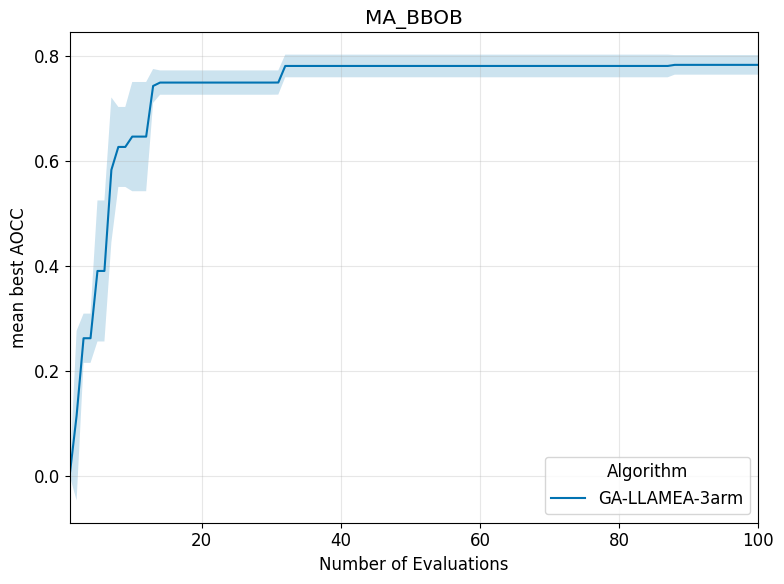

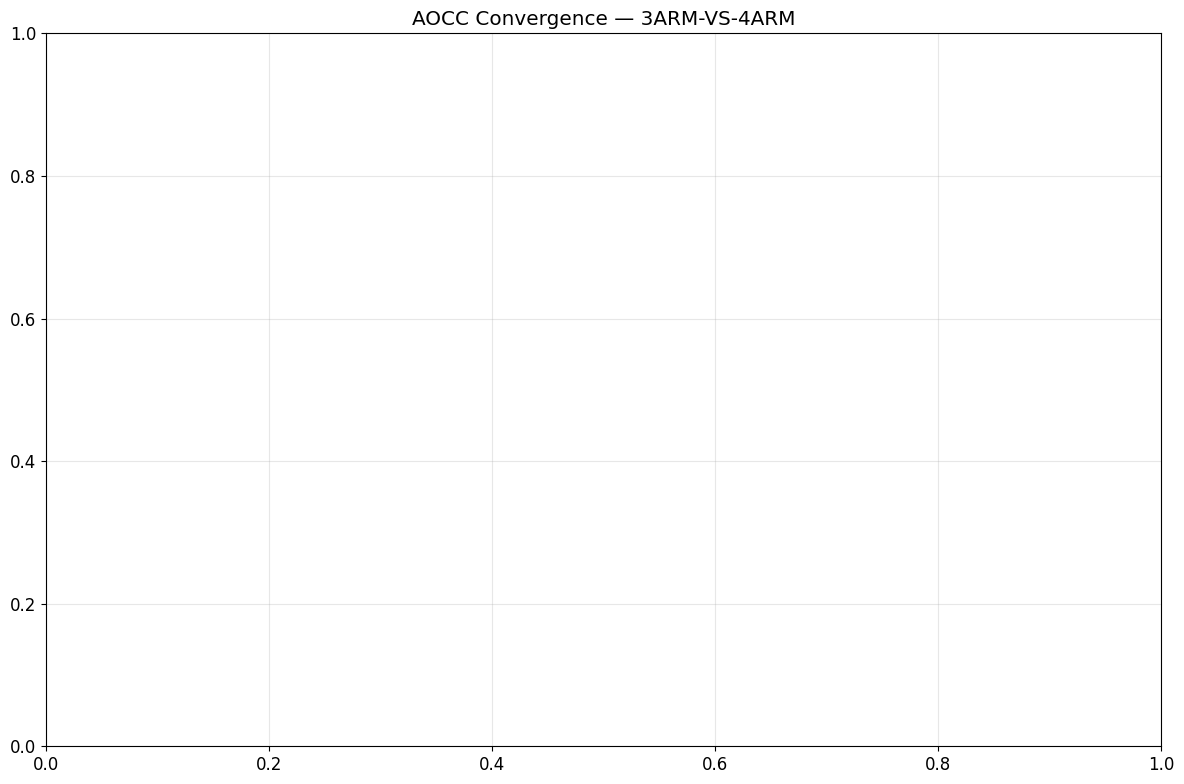

In [3]:
# AOCC Convergence (Area Over the Convergence Curve)
print('AOCC Convergence Plot')
try:
    plot_convergence(logger, metric='AOCC', save=False, budget=100)
    plt.title('AOCC Convergence — 3ARM-VS-4ARM')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Error plotting AOCC convergence: {e}')

Fitness Convergence Plot


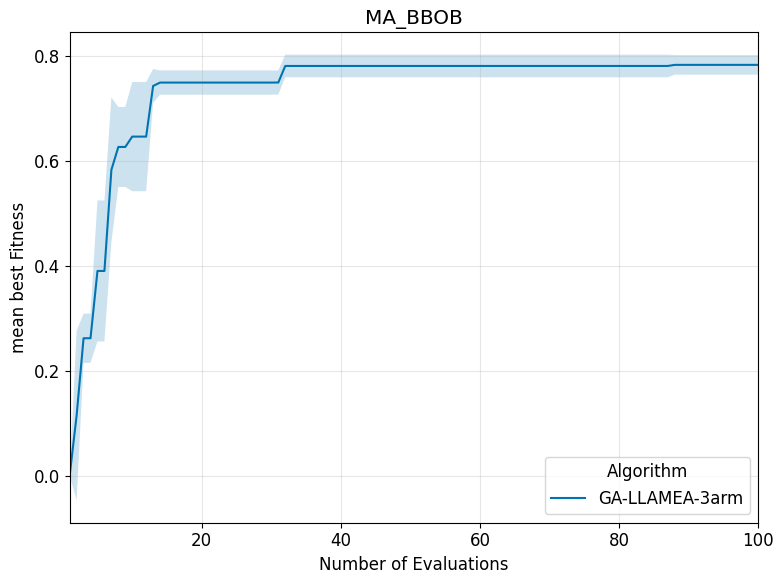

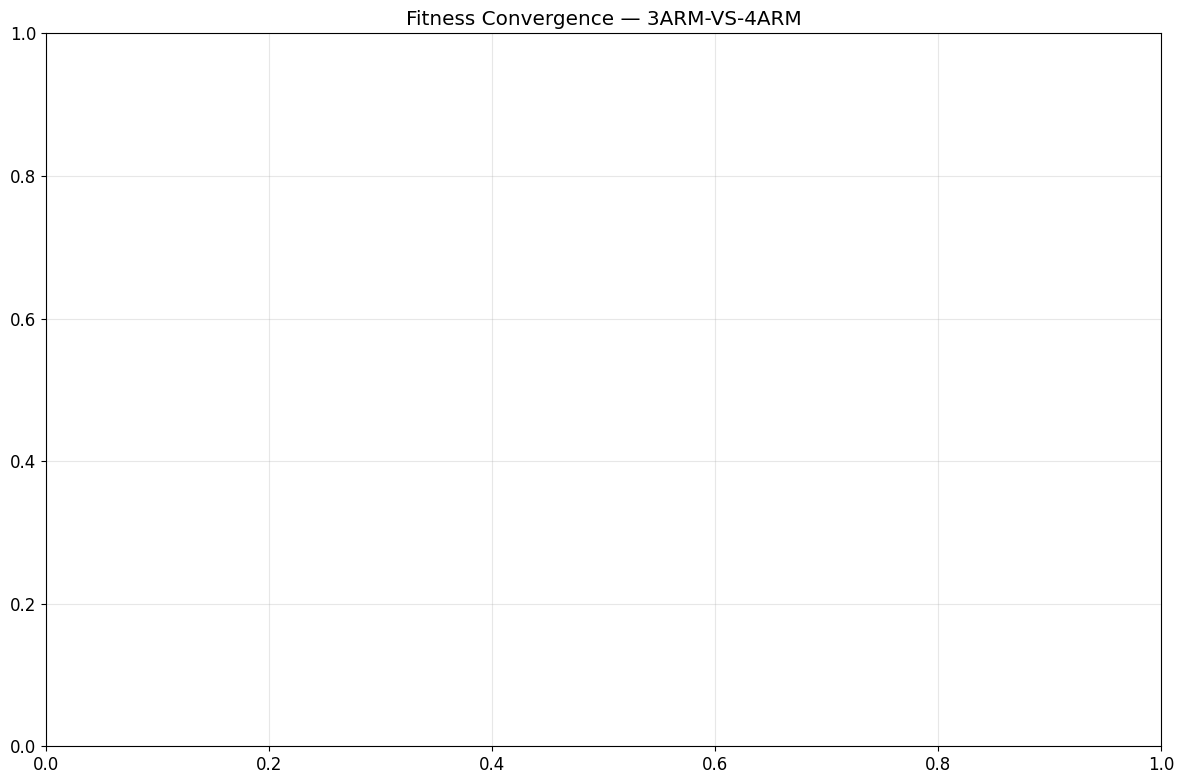

In [4]:
# Fitness Convergence
print('Fitness Convergence Plot')
try:
    plot_convergence(logger, metric='Fitness', save=False, budget=100)
    plt.title('Fitness Convergence — 3ARM-VS-4ARM')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Error plotting Fitness convergence: {e}')

## 3. CEG (Code Evolution Graphs)

Visualize how code complexity and quality evolve over the optimization budget for each run.

Code Evolution Graphs


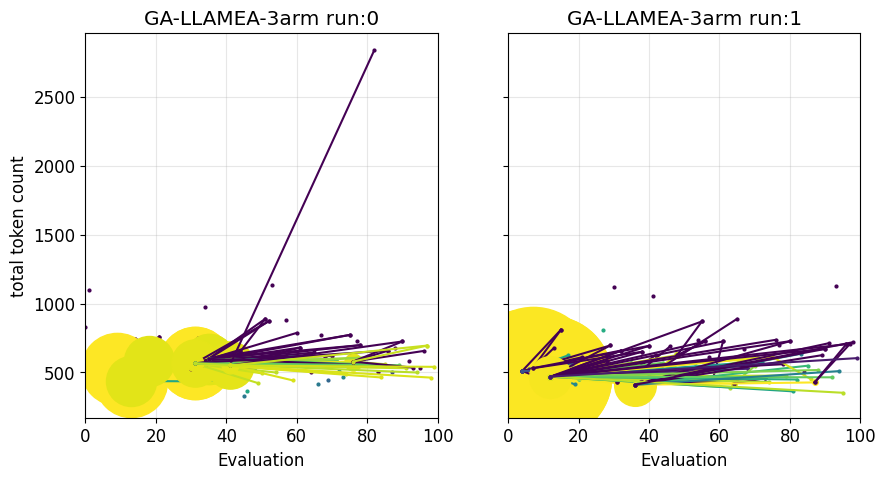

In [5]:
print('Code Evolution Graphs')
try:
    plot_experiment_CEG(logger, save=False, budget=100, max_seeds=10)
    plt.show()
except Exception as e:
    print(f'Error plotting CEG: {e}')

## 4. GA-LLAMEA Arm Selection Percentages

Visualize how the D-TS bandit distributes operator selections over the course of each GA-LLAMEA run. This shows whether the bandit learns to prefer certain operators over time.

The `operator` field from the log data is used to compute the cumulative selection percentage at each evaluation step.

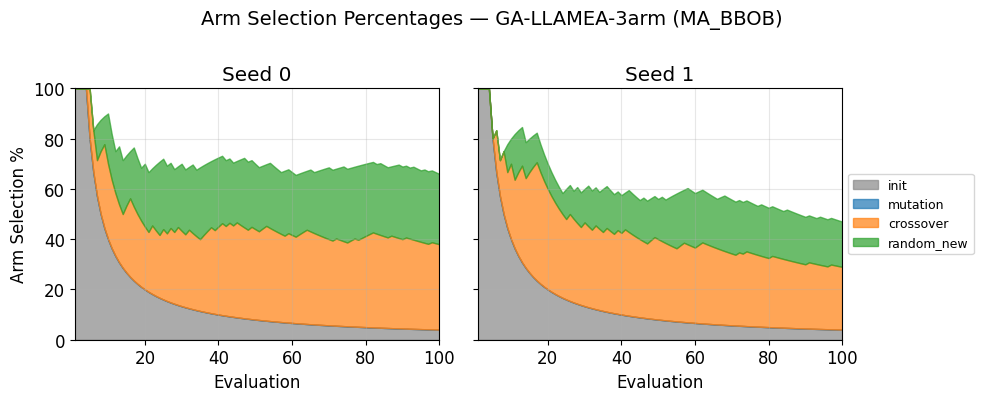

In [6]:
# Arm selection percentage over evaluations for GA-LLAMEA runs
try:
    ga_methods = [m for m in methods if 'GA-LLAMEA' in m.upper() or 'GA_LLAMEA' in m.upper()]
    if not ga_methods:
        print('No GA-LLAMEA methods found in the experiment.')
    else:
        for problem in problems:
            data = logger.get_problem_data(problem_name=problem)
            data.replace([-np.inf], 0, inplace=True)
            data.fillna(0, inplace=True)

            for ga_method in ga_methods:
                method_data = data[data['method_name'] == ga_method].copy()
                if method_data.empty:
                    print(f'No data for {ga_method}')
                    continue

                seeds = sorted(method_data['seed'].unique())
                num_seeds = len(seeds)

                # Create subplots for each seed
                n_cols = min(5, num_seeds)
                n_rows = (num_seeds + n_cols - 1) // n_cols
                
                fig, axes = plt.subplots(
                    n_rows, n_cols,
                    figsize=(5 * n_cols, 4 * n_rows),
                    squeeze=False,
                    sharey=True,
                )

                operator_colors = {
                    'init': '#888888',
                    'mutation': '#1f77b4',
                    'crossover': '#ff7f0e',
                    'random_new': '#2ca02c',
                    'refine_weakness': '#d62728',
                }
                
                # Determine operator order based on method
                if '3arm' in ga_method.lower():
                    operator_order = ['init', 'mutation', 'crossover', 'random_new']
                else:
                    operator_order = ['init', 'mutation', 'crossover', 'random_new', 'refine_weakness']

                for seed_i, seed in enumerate(seeds):
                    row = seed_i // n_cols
                    col = seed_i % n_cols
                    ax = axes[row, col]
                    
                    run_data = method_data[method_data['seed'] == seed].copy().reset_index(drop=True)

                    # Extract operator from top-level field; fall back to metadata
                    operators = []
                    for _, row_data in run_data.iterrows():
                        op = row_data.get('operator', None)
                        if op is None or (isinstance(op, float) and np.isnan(op)):
                            meta = row_data.get('metadata', {})
                            if isinstance(meta, dict):
                                op = meta.get('operator', 'unknown')
                            else:
                                op = 'unknown'
                        operators.append(op)

                    # Compute cumulative percentages
                    eval_indices = list(range(1, len(operators) + 1))
                    cumulative = {op: [] for op in operator_order}
                    counts = {op: 0 for op in operator_order}

                    for i, op in enumerate(operators):
                        if op in counts:
                            counts[op] += 1
                        total = i + 1
                        for op_name in operator_order:
                            cumulative[op_name].append(counts[op_name] / total * 100)

                    # Stacked area plot
                    bottoms = np.zeros(len(eval_indices))
                    for op_name in operator_order:
                        values = np.array(cumulative[op_name])
                        ax.fill_between(
                            eval_indices, bottoms, bottoms + values,
                            alpha=0.7, label=op_name,
                            color=operator_colors.get(op_name, '#999999'),
                        )
                        bottoms += values

                    ax.set_xlim([1, len(operators)])
                    ax.set_ylim([0, 100])
                    ax.set_xlabel('Evaluation')
                    ax.set_title(f'Seed {seed}')
                    if col == 0:
                        ax.set_ylabel('Arm Selection %')

                # Hide unused subplots
                for idx in range(num_seeds, n_rows * n_cols):
                    row = idx // n_cols
                    col = idx % n_cols
                    axes[row, col].set_visible(False)

                # Add legend to the last visible subplot
                if num_seeds > 0:
                    last_row = (num_seeds - 1) // n_cols
                    last_col = (num_seeds - 1) % n_cols
                    axes[last_row, last_col].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)

                fig.suptitle(f'Arm Selection Percentages — {ga_method} ({problem})', fontsize=14, y=1.00)
                plt.tight_layout()
                plt.show()

except Exception as e:
    import traceback
    traceback.print_exc()
    print(f'Error plotting arm percentages: {e}')

## 5. Boxplots (Fitness Comparison)

Distribution of final fitness values found by each method.

Fitness Boxplot (grouped by method)


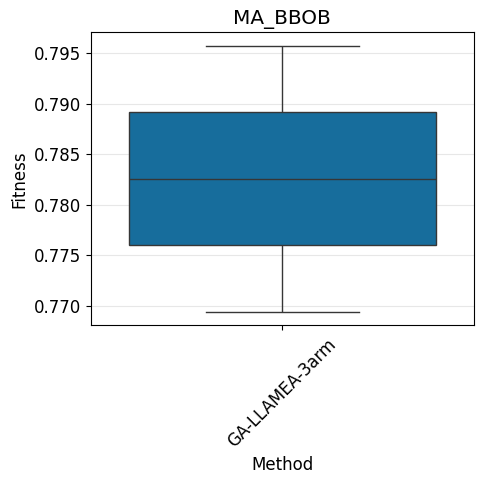

<Figure size 1200x800 with 0 Axes>

In [7]:
# Standard boxplot
print('Fitness Boxplot (grouped by method)')
try:
    plot_boxplot_fitness(logger)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Error plotting fitness boxplot: {e}')

Fitness Boxplot with Hue


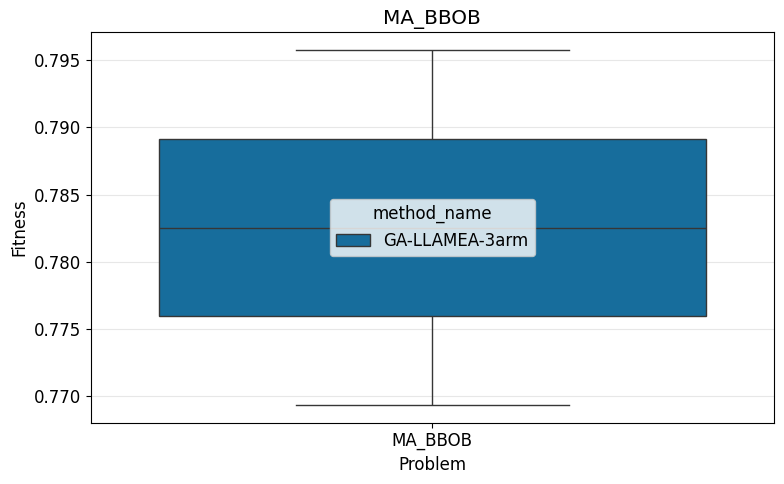

<Figure size 1200x800 with 0 Axes>

In [8]:
# Boxplot with hue distinction
print('Fitness Boxplot with Hue')
try:
    plot_boxplot_fitness_hue(logger)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Error plotting fitness boxplot (hue): {e}')

## 6. Fitness Table (Statistical Summary)

Tabular summary of fitness statistics with mean, standard deviation, and p-values (Wilcoxon test).

In [9]:
print('Fitness Table (mean +/- std with p-values)')
try:
    table = fitness_table(logger)
    print(table)
except Exception as e:
    print(f'Error generating fitness table: {e}')

Fitness Table (mean +/- std with p-values)
                              MA_BBOB
GA-LLAMEA-3arm  0.78 ± 0.01 (p=1.000)


## 7. Behavior Metrics Analysis

Compute and visualize exploration/exploitation behavior metrics for each method.

Since BLADE LLM experiments produce code solutions (not numeric coordinate vectors), we project code strings into a latent coordinate space using TF-IDF + TruncatedSVD before computing spatial diversity metrics.

In [10]:
def safe_compute_metrics(df):
    """Compute behavior metrics, projecting code to coordinate space if needed."""
    # Ensure required columns exist
    if 'raw_y' not in df.columns and 'fitness' in df.columns:
        df['raw_y'] = df['fitness']
    if 'evaluations' not in df.columns:
        df = df.reset_index(drop=True)
        df['evaluations'] = df.index + 1

    # Check for x columns
    x_cols = [c for c in df.columns if c.startswith('x')]

    # If no x columns but we have code, project code to latent space
    if not x_cols and 'code' in df.columns:
        try:
            vectorizer = TfidfVectorizer(max_features=1000)
            code_data = df['code'].fillna('').astype(str)
            if len(code_data) > 1:
                X_tfidf = vectorizer.fit_transform(code_data)
                n_components = min(10, len(df) - 1, X_tfidf.shape[1] - 1)
                if n_components > 1:
                    svd = TruncatedSVD(n_components=n_components, random_state=42)
                    X_reduced = svd.fit_transform(X_tfidf)
                    for i in range(n_components):
                        df[f'x{i}'] = X_reduced[:, i]
                    x_cols = [f'x{i}' for i in range(n_components)]
        except Exception as e:
            print(f'  Warning: Code projection failed: {e}')

    if not x_cols:
        return None

    try:
        metrics = compute_behavior_metrics(df)
        return metrics
    except Exception as e:
        print(f'  Warning: compute_behavior_metrics failed: {e}')
        return None

print('Behavior metrics helper defined.')

Behavior metrics helper defined.


In [11]:
# Collect behavior metrics from all runs
all_metrics = []

run_dirs = [d for d in os.listdir(EXPERIMENT_DIR)
            if os.path.isdir(os.path.join(EXPERIMENT_DIR, d)) and d.startswith('run-')]

for run_dir in sorted(run_dirs):
    log_path = os.path.join(EXPERIMENT_DIR, run_dir, 'log.jsonl')
    if not os.path.exists(log_path):
        continue

    # Parse method name and seed from directory name
    parts = run_dir.replace('run-', '').split('-MA_BBOB-')
    method_name = parts[0] if parts else run_dir
    seed = parts[1] if len(parts) > 1 else '?'

    print(f'Processing: {run_dir} (method={method_name}, seed={seed})')

    # Read log.jsonl
    rows = []
    with open(log_path, 'r') as f:
        for line in f:
            try:
                entry = json.loads(line.strip())
                # Support both formats: fields at top level (log.jsonl)
                # or nested inside a 'solution' key (experimentlog.jsonl)
                sol = entry.get('solution', entry)
                rows.append({
                    'fitness': sol.get('fitness', None),
                    'code': sol.get('code', ''),
                    'name': sol.get('name', ''),
                    'generation': sol.get('generation', None),
                })
            except json.JSONDecodeError:
                continue

    if not rows:
        continue

    df_run = pd.DataFrame(rows)
    df_run['fitness'] = pd.to_numeric(df_run['fitness'].astype(str).replace('-inf', '-inf'), errors='coerce')
    df_run = df_run.dropna(subset=['fitness'])
    df_run = df_run.reset_index(drop=True)
    df_run['evaluations'] = df_run.index + 1
    df_run['raw_y'] = df_run['fitness'].astype(float)

    if len(df_run) < 3:
        print(f'  Skipping: too few data points ({len(df_run)})')
        continue

    metrics = safe_compute_metrics(df_run.copy())
    if metrics is not None:
        metrics['method'] = method_name
        metrics['seed'] = seed
        metrics['run_dir'] = run_dir
        all_metrics.append(metrics)
        print(f'  OK - {len(metrics)} metrics computed')
    else:
        print(f'  Skipping: metrics computation returned None')

print(f'\nTotal runs with metrics: {len(all_metrics)}')

Processing: run-GA-LLAMEA-3arm-MA_BBOB-0 (method=GA-LLAMEA-3arm, seed=0)
  Skipping: metrics computation returned None
Processing: run-GA-LLAMEA-3arm-MA_BBOB-1 (method=GA-LLAMEA-3arm, seed=1)
  Skipping: metrics computation returned None
Processing: run-GA-LLAMEA-3arm-MA_BBOB-2 (method=GA-LLAMEA-3arm, seed=2)
  Skipping: metrics computation returned None
Processing: run-GA-LLAMEA-3arm-MA_BBOB-3 (method=GA-LLAMEA-3arm, seed=3)
  Skipping: metrics computation returned None
Processing: run-GA-LLAMEA-3arm-MA_BBOB-4 (method=GA-LLAMEA-3arm, seed=4)
  Skipping: metrics computation returned None
Processing: run-GA-LLAMEA-3arm-MA_BBOB-5 (method=GA-LLAMEA-3arm, seed=5)
  Skipping: metrics computation returned None
Processing: run-GA-LLAMEA-3arm-MA_BBOB-6 (method=GA-LLAMEA-3arm, seed=6)
  Skipping: metrics computation returned None
Processing: run-GA-LLAMEA-3arm-MA_BBOB-7 (method=GA-LLAMEA-3arm, seed=7)
  Skipping: metrics computation returned None
Processing: run-GA-LLAMEA-3arm-MA_BBOB-8 (method

In [12]:
# Display behavior metrics table
if all_metrics:
    df_metrics = pd.DataFrame(all_metrics)

    # Select key metric columns
    metric_cols = [c for c in df_metrics.columns
                   if c not in ('method', 'seed', 'run_dir')]
    display_cols = ['method', 'seed'] + metric_cols

    print('=== Behavior Metrics per Run ===')
    print(df_metrics[display_cols].to_string(index=False, float_format='{:.4f}'.format))
else:
    print('No behavior metrics could be computed.')

No behavior metrics could be computed.


In [13]:
# Visualize key behavior metrics as grouped bar charts
if all_metrics:
    df_metrics = pd.DataFrame(all_metrics)

    # Key metrics to visualize
    key_metrics = [
        'avg_nearest_neighbor_distance',
        'dispersion',
        'avg_distance_to_best',
        'success_rate',
        'average_convergence_rate',
        'longest_no_improvement_streak',
    ]

    # Filter to only metrics that exist
    available_metrics = [m for m in key_metrics if m in df_metrics.columns]

    if available_metrics:
        n_metrics = len(available_metrics)
        n_cols = min(3, n_metrics)
        n_rows = (n_metrics + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
        if n_metrics == 1:
            axes = [axes]
        elif n_rows > 1 or n_cols > 1:
            axes = axes.flatten()
        else:
            axes = [axes]

        for idx, metric_name in enumerate(available_metrics):
            ax = axes[idx]
            sns.barplot(
                data=df_metrics,
                x='method',
                y=metric_name,
                ax=ax,
                errorbar='sd',
            )
            ax.set_title(metric_name.replace('_', ' ').title())
            ax.set_xlabel('Method')
            ax.set_ylabel('')
            ax.tick_params(axis='x', rotation=30)

        # Hide unused axes
        for idx in range(len(available_metrics), len(axes)):
            axes[idx].set_visible(False)

        fig.suptitle('Behavior Metrics Comparison — 3ARM-VS-4ARM',
                     fontsize=14, fontweight='bold', y=1.00)
        plt.tight_layout()
        plt.show()
    else:
        print('No key metrics available for visualization.')
else:
    print('No behavior metrics to visualize.')

No behavior metrics to visualize.


## 8. Summary and Comparison

### Key Findings

| Aspect | GA-LLAMEA-3arm | GA-LLAMEA-4arm |
|--------|----------------|----------------|
| Operators | mutation, crossover, random_new | mutation, crossover, random_new, refine_weakness |
| Population | 4 parents, 8 offspring | 4 parents, 8 offspring |
| Elitism | Yes | Yes |
| LLM | gemini-2.0-flash | gemini-2.0-flash |
| Budget | 100 evaluations | 100 evaluations |
| Runs | 10 | 10 |

### Observations

Refer to the convergence plots, boxplots, fitness table, and behavior metrics above to draw conclusions about:

1. **Convergence Speed** — Which configuration converges fastest to high-quality solutions?
2. **Final Fitness** — Which configuration achieves the best final AOCC scores?
3. **Consistency** — Which configuration has the lowest variance across seeds?
4. **Exploration vs. Exploitation** — How do the behavior metrics differ?
5. **Operator Selection** — Does the 4-arm bandit learn different operator preferences compared to the 3-arm version?

The behavior metrics (nearest-neighbor distance, dispersion, success rate, convergence rate) provide insight into the search dynamics of each configuration.